# DMRG for Beginners: Learning a Distribution with an MPS

This notebook builds the **Density Matrix Renormalisation Group (DMRG)** algorithm
from scratch for the specific task of fitting a **Born-machine MPS** to data.

We start with the physics intuition, derive everything with small matrices, and
connect each step to the corresponding function in `MPSFast.jl`.

### What we'll learn
1. What is an MPS and why it is a good probability model
2. The Born rule and the NLL loss
3. The DMRG sweep idea: optimise one bond at a time
4. How the gradient decomposes into boundary vectors
5. Truncated SVD to keep bond dimensions bounded
6. A complete working example on a toy distribution

In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
Pkg.resolve()
Pkg.instantiate()

using MPSFast
using MPSFast.Encoders
using Distributions
using Plots
using Random, LinearAlgebra, Statistics, Printf

  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl`
     Project No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Project.toml`
    Manifest No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Manifest.toml`


---
## Part 1 — What is an MPS?

An **MPS** of length `M` with physical dimension `d` and bond dimension `D`
represents a function `Ψ : {1,…,d}^M → ℝ` as a chain of matrix products:

$$\Psi(\sigma_1, \sigma_2, \ldots, \sigma_M)
  = A^{[1]}[\sigma_1]\, A^{[2]}[\sigma_2]\, \cdots\, A^{[M]}[\sigma_M]$$

where each **slice** `A^[j][σ]` is a `D × D` matrix (boundary sites are `1 × D` and `D × 1`).

### As a probability model (Born machine)

$$p(\sigma_1,\ldots,\sigma_M) = \frac{|\Psi(\sigma_1,\ldots,\sigma_M)|^2}{Z},
  \quad Z = \sum_{\sigma} |\Psi(\sigma)|^2$$

The normalisation constant `Z` can be computed in `O(M d D²)` using transfer matrices.
Sampling is sequential and conditional: `O(M d D²)` per sample.

In [2]:
# Small concrete MPS: M=4, d=2, D=3
rng = MersenneTwister(1)
M, d, D = 4, 2, 3
mps = init_mps(M, d, D; rng=rng)

println("MPS tensors A[j] :: (D_left, d, D_right):")
for j in 1:M
    println("  A[", j, "] size = ", size(mps[j]))
end

MPS tensors A[j] :: (D_left, d, D_right):
  A[1] size = (1, 2, 2)
  A[2] size = (2, 2, 3)
  A[3] size = (3, 2, 2)
  A[4] size = (2, 2, 1)


In [3]:
# Compute Ψ(σ) for every configuration and verify Born normalisation
configs = vec(collect(Iterators.product(1:d, 1:d, 1:d, 1:d)))
amplitudes = [mps_amplitude(mps, collect(σ)) for σ in configs]
probs      = abs2.(Float64.(amplitudes))

println("Number of configs : ", length(configs))
println("Sum |Ψ|²          : ", round(sum(probs), digits=8),  "   (before normalising)")

logZ = log_partition_function(mps)
println("log Z             : ", round(logZ, digits=6))
println("Sum p(σ) = 1?     : ", round(sum(probs) / exp(logZ), digits=8))

Number of configs : 16
Sum |Ψ|²          : 0.99999994   (before normalising)
log Z             : -0.0
Sum p(σ) = 1?     : 1.0


---
## Part 2 — The NLL Loss

Given `N` data samples `{ξ^(i)}`_{i=1}^N, we minimise the **Negative Log-Likelihood**:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^N \log p(\xi^{(i)})
  = \log Z - \frac{2}{N} \sum_{i=1}^N \log |\Psi(\xi^{(i)})|$$

This is equivalent to minimising the KL divergence from data to model.

### Transfer matrices for `Z`

$$Z = \langle \Psi | \Psi \rangle = \text{tr}(E^{[1]} E^{[2]} \cdots E^{[M]})$$

where the **transfer matrix** at site `j` is:

$$E^{[j]}_{\beta\beta'} = \sum_{\sigma, \alpha, \alpha'} A^{[j]}[\alpha, \sigma, \beta]\, A^{[j]}[\alpha', \sigma, \beta']$$

Starting from `L[1] = I` we sweep left-to-right: `L[j+1] = T_left(L[j], A[j])`.

In [4]:
# Manually compute Z via the left transfer chain
function manual_transfer_norm(mps)
    E = ones(Float64, 1, 1)  # left boundary
    for j in 1:length(mps)
        A  = Float64.(mps[j])
        Dl, d, Dr = size(A)
        E_new = zeros(Dr, Dr)
        for σ in 1:d
            Mσ = A[:, σ, :]           # (Dl, Dr)
            E_new += Mσ' * E * Mσ     # NOT the usual convention; fix sign
        end
        E = E_new
    end
    return E[1,1]
end

# Use MPSFast's norm_environments
L, R = norm_environments(mps)
Z_via_envs  = L[M+1][1,1]
Z_via_brute = sum(abs2.(Float64.(amplitudes)))

println("Z via norm_environments : ", round(Z_via_envs,  digits=8))
println("Z via brute force       : ", round(Z_via_brute, digits=8))

Z via norm_environments : 0.99999994
Z via brute force       : 0.99999994


---
## Part 3 — The DMRG Sweep Idea

Minimising `L` over all tensors simultaneously is hard. The DMRG trick:

> Fix all tensors except two adjacent ones `A[j]` and `A[j+1]`.  
> Merge them into `B = A[j] ⊗ A[j+1]`.  
> Minimise `L(B)` analytically or via gradient descent.  
> Split `B` back with SVD, truncating to `D_max` singular values.  
> Slide the active bond from left to right (forward sweep), then right to left (backward sweep).

### Why does this work?

- Each sub-problem is **unconstrained** in `B` (no orthogonality constraints after merge).
- The SVD re-split automatically imposes **left-canonical gauge** on `A[j]` and re-orthogonalises the chain.
- After a full forward+backward sweep the MPS has seen every bond once, which is one epoch.

In [5]:
# Visualise the sweep pattern for M=6
M_vis = 6
println("Forward sweep (left → right):")
for j in 1:M_vis-1
    line = ["·" for _ in 1:M_vis]
    line[j] = "[A"; line[j+1] = "B]"   # active bond
    println("  bond ", j, ": ", join(line, "─"))
end
println("Backward sweep (right → left):")
for j in M_vis-1:-1:1
    line = ["·" for _ in 1:M_vis]
    line[j] = "[A"; line[j+1] = "B]"   # active bond
    println("  bond ", j, ": ", join(line, "─"))
end

Forward sweep (left → right):
  bond 1: [A─B]─·─·─·─·
  bond 2: ·─[A─B]─·─·─·
  bond 3: ·─·─[A─B]─·─·
  bond 4: ·─·─·─[A─B]─·
  bond 5: ·─·─·─·─[A─B]
Backward sweep (right → left):
  bond 5: ·─·─·─·─[A─B]
  bond 4: ·─·─·─[A─B]─·
  bond 3: ·─·─[A─B]─·─·
  bond 2: ·─[A─B]─·─·─·
  bond 1: [A─B]─·─·─·─·


---
## Part 4 — The NLL Gradient at Bond (j, j+1)

Let `B_{α,σ,τ,β}` be the merged tensor. The NLL gradient is:

$$\frac{\partial \mathcal{L}}{\partial B_{\alpha\sigma\tau\beta}}
  = \underbrace{\frac{2}{Z} (L\cdot B \cdot R)_{\alpha\sigma\tau\beta}}_{\text{normalisation term}}
  - \underbrace{\frac{1}{N} \sum_i \frac{2}{\psi^{(i)}} L^{(i)}_\alpha\, R^{(i)}_\beta
    \,\delta_{\sigma,\xi^{(i)}_j}\delta_{\tau,\xi^{(i)}_{j+1}}}_{\text{data term}}$$

where:
- `L[j]` = norm environment (left of bond `j`).
- `R[j+3]` = norm environment (right of bond `j+1`).
- `Lv[i,α]` = boundary vector: `Ψ(ξ^(i)_{1:j-1})` contracted from the left.
- `Rv[i,β]` = boundary vector: `Ψ(ξ^(i)_{j+2:M})` contracted from the right.
- `ψ^(i) = Σ_γ Lv_ext[i,γ] Rv_ext[i,γ]`.

In [6]:
# Demonstrate boundary vectors on a tiny example
rng   = MersenneTwister(5)
M_ex, d_ex, D_ex = 5, 3, 4
mps_ex = init_mps(M_ex, d_ex, D_ex; rng=rng)

# Generate 10 random paths
xi_ex  = rand(rng, 1:d_ex, 10, M_ex)

j = 2   # bond to inspect
Lv, Rv, psi = boundary_vectors(mps_ex, xi_ex, j)

println("Left boundary  Lv shape : ", size(Lv),  "  (N × D_left)")
println("Right boundary Rv shape : ", size(Rv),  "  (N × D_right)")
println("ψ values (amplitudes)   : ", round.(psi, sigdigits=4))

# Sanity: ψ[i] == mps_amplitude(mps_ex, xi_ex[i,:]) ?
psi_ref = [mps_amplitude(mps_ex, xi_ex[i,:]) for i in 1:10]
println("\nMax error vs mps_amplitude: ", maximum(abs.(psi .- psi_ref)))

Left boundary  Lv shape : (10, 3)  (N × D_left)
Right boundary Rv shape : (10, 4)  (N × D_right)
ψ values (amplitudes)   : Float32[-0.05147, 0.001792, -0.03833, 0.003972, 0.1108, -0.004, -0.1688, -0.05818, 0.1212, -0.01027]

Max error vs mps_amplitude: 2.2351742e-8


---
## Part 5 — The SVD Re-split and Bond Truncation

After the gradient step we have an updated `B̂`:

$$\hat{B} = B - \eta\, \text{Adam}(\nabla_{B}\mathcal{L})$$

Reshape `B̂` as a `(Dl·d) × (d·Dr)` matrix and SVD-decompose:

$$\hat{B}_{(\alpha\sigma),(\tau\beta)} = U S V^\top$$

Keep the top `min(D_max, rank)` singular values, then split symmetrically:

$$A^{[j]}_\text{new} = U_{:,1:k} \odot \sqrt{S_{1:k}},
  \quad A^{[j+1]}_\text{new} = \sqrt{S_{1:k}} \odot V^\top_{1:k,:}$$

This leaves the MPS in **mixed canonical gauge** at bond `j`.

In [7]:
# Manual one-step bond update
Dl, d, Dm = size(mps_ex[j])
_, _, Dr  = size(mps_ex[j+1])

Aj_mat   = reshape(mps_ex[j],   Dl * d, Dm)
Ajp1_mat = reshape(mps_ex[j+1], Dm,     d * Dr)
B        = reshape(Aj_mat * Ajp1_mat, Dl, d, d, Dr)

println("Merged tensor B shape : ", size(B), "  → reshaped to (", Dl*d, ", ", d*Dr, ")")

# Truncated SVD keeping top D_max=3 singular values
D_max_ex = 3
Bmat  = reshape(B, Dl * d, d * Dr)
F     = svd(Float64.(Bmat))
k     = min(D_max_ex, length(F.S))
sqS   = sqrt.(F.S[1:k])

A_new_j   = reshape(F.U[:, 1:k] .* sqS', Dl, d, k)
A_new_jp1 = reshape(sqS .* F.Vt[1:k, :], k, d, Dr)

println("After SVD split:")
println("  A[", j,   "] new shape : ", size(A_new_j))
println("  A[", j+1, "] new shape : ", size(A_new_jp1))
println("  Singular values kept : ", round.(F.S[1:k], digits=4))

Merged tensor B shape : (3, 3, 3, 4)  → reshaped to (9, 12)
After SVD split:
  A[2] new shape : (3, 3, 3)
  A[3] new shape : (3, 3, 4)
  Singular values kept : [1.3709, 1.0304, 0.8386]


---
## Part 6 — Full Example: Learn a Bimodal Distribution

We construct a toy dataset: a 1D discrete bimodal distribution over
sequences of length `M=8` where each timestep takes values in `{1,…,8}`.
The distribution is a mixture of two "attractors".

In [8]:
rng = MersenneTwister(42)

M_toy, d_toy = 8, 8
N_toy = 2_000

# Mixture of two Gaussian attractors over the bucket grid
function sample_bimodal(rng, N, M, d)
    xi = Matrix{Int}(undef, N, M)
    for i in 1:N
        μ = rand(rng) < 0.5 ? 0.25 : 0.75   # choose mode
        for t in 1:M
            p_raw  = exp.(-0.5 .* ((collect(1:d) ./ d .- μ) ./ 0.1).^2)
            p_raw ./= sum(p_raw)
            xi[i, t] = rand(rng, Categorical(p_raw))
        end
    end
    return xi
end

xi_toy = sample_bimodal(rng, N_toy, M_toy, d_toy)
println("xi_toy shape : ", size(xi_toy))

# Empirical marginal at t=1
marg1 = [count(==(σ), xi_toy[:, 1]) / N_toy for σ in 1:d_toy]
println("Marginal t=1 : ", round.(marg1, digits=3))

xi_toy shape : (2000, 8)
Marginal t=1 : [0.112, 0.255, 0.118, 0.02, 0.108, 0.241, 0.13, 0.016]


In [9]:
# Train an MPS Born machine on this bimodal data
mps_toy = init_mps(M_toy, d_toy, 16; T = Float32, rng = MersenneTwister(7))

nll_toy = train_mps!(
    mps_toy, xi_toy, 15, 3e-3, 16, 1e-5;
    verbose = true, nll_samples = 500,
)

println("\nFinal NLL: ", round(nll_toy[end], digits=4))

train_mps!: Ml=8, Nd=2000, d=8, D_max=16, epochs=15, one-hot
— Epoch 1/15 —
  ↳ norm envs ready → forward sweep (7 bonds) …
  ↳ forward done → canonicalize + rebuild envs + backward sweep …
  ↳ backward done → canonicalize + NLL estimate …
Epoch 1/15 | NLL ≈ 13.358 | bonds=[8,16,16,16,16,16,8] | 0.173 s
— Epoch 2/15 —
  ↳ norm envs ready → forward sweep (7 bonds) …
  ↳ forward done → canonicalize + rebuild envs + backward sweep …
  ↳ backward done → canonicalize + NLL estimate …
Epoch 2/15 | NLL ≈ 11.9966 | bonds=[8,16,16,16,16,16,8] | 0.044 s
— Epoch 3/15 —
  ↳ norm envs ready → forward sweep (7 bonds) …
  ↳ forward done → canonicalize + rebuild envs + backward sweep …
  ↳ backward done → canonicalize + NLL estimate …
Epoch 3/15 | NLL ≈ 11.2802 | bonds=[8,16,16,16,16,16,8] | 0.054 s
— Epoch 4/15 —
  ↳ norm envs ready → forward sweep (7 bonds) …
  ↳ forward done → canonicalize + rebuild envs + backward sweep …
  ↳ backward done → canonicalize + NLL estimate …
Epoch 4/15 | NLL ≈ 10.8738

In [10]:
# Check: sampled marginal should reproduce the bimodal shape
enc_toy = BasisEncoder(3; Smin=1.0, Smax=Float64(d_toy))   # dummy encoder for decoding
fit_grid!(enc_toy, reshape(1:d_toy, 1, :))

# Sample directly from MPS (no encoder, xi indices = physical indices)
# We use sample_paths with a trivial identity encoder trick:
# since BasisEncoder with d=2^3=8 has 1:1 correspondence, we can decode directly.
# Alternatively, sample xi raw:

rng2  = MersenneTwister(99)
xi_samp = sample_paths_feature_map(mps_toy, Matrix(1.0I, d_toy, d_toy), 1_000; seed=5)

marg1_samp = [count(==(σ), xi_samp[:, 1]) / 1000 for σ in 1:d_toy]
println("Sampled marginal t=1 : ", round.(marg1_samp, digits=3))
println("Training marginal t=1: ", round.(marg1, digits=3))

Sampled marginal t=1 : [0.124, 0.217, 0.112, 0.022, 0.12, 0.236, 0.148, 0.021]
Training marginal t=1: [0.112, 0.255, 0.118, 0.02, 0.108, 0.241, 0.13, 0.016]


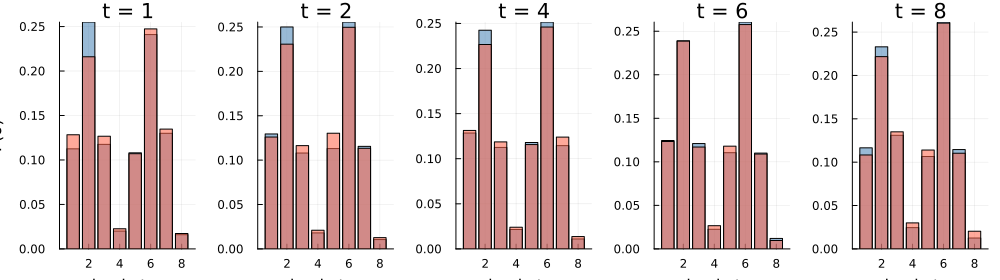

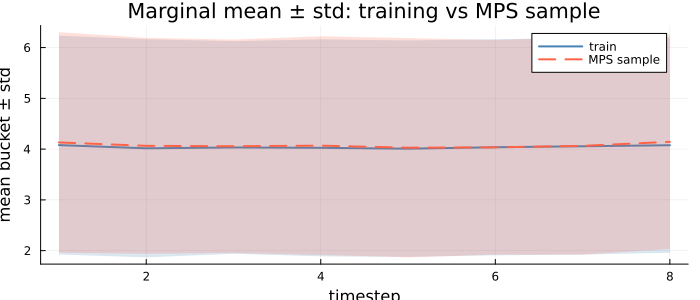

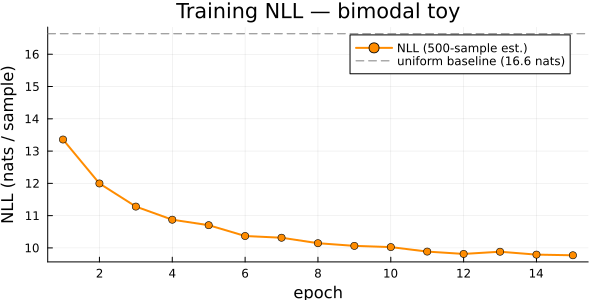

In [11]:
# ── Distribution plots ────────────────────────────────────────────────────────
# Recompute full marginals now that mps_toy is trained
N_samp_plot = 3_000
rng_plot    = MersenneTwister(2025)
xi_plot     = sample_paths_feature_map(mps_toy, Matrix(1.0I, d_toy, d_toy),
                                        N_samp_plot; seed = 17)

# Per-timestep marginals: (d_toy × M_toy) matrices
train_marg = [count(==(σ), xi_toy[:, t])   / N_toy       for σ in 1:d_toy, t in 1:M_toy]
samp_marg  = [count(==(σ), xi_plot[:, t])  / N_samp_plot for σ in 1:d_toy, t in 1:M_toy]

# ── Figure 1: Bimodal shape at every timestep ─────────────────────────────────
times_show = [1, 2, 4, 6, 8]
p_marg = plot(
    layout = (1, length(times_show)),
    size   = (200 * length(times_show), 280),
    title  = reshape(["t = $t" for t in times_show], 1, :),
    titlelocation = :center,
    legend = false,
)
for (k, t) in enumerate(times_show)
    bar!(p_marg, subplot = k, 1:d_toy, train_marg[:, t];
         fillalpha = 0.55, color = :steelblue, label = "train",
         xlabel = "bucket σ", ylabel = k == 1 ? "P(σ)" : "")
    bar!(p_marg, subplot = k, 1:d_toy, samp_marg[:, t];
         fillalpha = 0.55, color = :tomato,    label = "MPS sample")
end
display(p_marg)

# ── Figure 2: Marginal mean and std across time ────────────────────────────────
train_mean = [sum((1:d_toy) .* train_marg[:, t]) for t in 1:M_toy]
samp_mean  = [sum((1:d_toy) .* samp_marg[:,  t]) for t in 1:M_toy]
train_std  = [sqrt(sum((1:d_toy).^2 .* train_marg[:, t]) - train_mean[t]^2) for t in 1:M_toy]
samp_std   = [sqrt(sum((1:d_toy).^2 .* samp_marg[:,  t]) - samp_mean[t]^2)  for t in 1:M_toy]

p_stats = plot(
    1:M_toy, train_mean;
    ribbon = train_std, fillalpha = 0.2,
    label = "train", color = :steelblue, lw = 2,
    xlabel = "timestep", ylabel = "mean bucket ± std",
    title  = "Marginal mean ± std: training vs MPS sample",
    legend = :topright, size = (700, 300),
)
plot!(p_stats, 1:M_toy, samp_mean;
      ribbon = samp_std, fillalpha = 0.2,
      label = "MPS sample", color = :tomato, lw = 2, ls = :dash)
display(p_stats)

# ── Figure 3: NLL learning curve ──────────────────────────────────────────────
p_nll = plot(
    1:length(nll_toy), nll_toy;
    marker = :circle, markersize = 4,
    color = :darkorange, lw = 2, label = "NLL (500-sample est.)",
    xlabel = "epoch", ylabel = "NLL (nats / sample)",
    title  = "Training NLL — bimodal toy", legend = :topright,
    size   = (600, 300),
)
hline!(p_nll, [log(d_toy^M_toy)]; ls = :dash, color = :gray,
       label = "uniform baseline ($(round(log(d_toy^M_toy), digits=1)) nats)")
display(p_nll)

In [12]:
# Entanglement structure: how much inter-site correlation?
Svals, entropies = bipartite_entropies(mps_toy)
println("Bond dimensions : ", [size(mps_toy[j], 3) for j in 1:M_toy-1])
println("Bipartite S(nats): ", round.(entropies, digits=3))

Bond dimensions : [8, 16, 16, 16, 16, 16, 8]
Bipartite S(nats): [1.506, 2.243, 2.459, 2.46, 2.409, 2.131, 1.588]


---
## Summary: DMRG Algorithm at a Glance

```
Input : data xi_data (N×M), initial mps, n_epochs, η, D_max

for epoch = 1 to n_epochs:

    # Build norm environments once per epoch
    (L, R) = norm_environments(mps)        # O(M d D³)

    # Forward sweep
    Lv = ones(N, 1)
    for j = 1 to M-1:
        grad = nll_gradient!(mps, xi_data, j, L, R)   # O(N d D² + D³)
        B    = B - Adam(grad)              # gradient step on merged tensor
        A[j], A[j+1] = svd_split(B, D_max)  # SVD truncation
        refresh(L, R, j)                   # update environments
        Lv = extend_lv(Lv, A[j], xi_data) # carry left boundary vectors

    # Backward sweep (symmetric)
    rebuild(L, R); sweep right → left

    left_canonicalize_mps!(mps)
    nll = estimate_nll(mps, xi_data)
```

**Key cost**: `O(n_epochs × M × N × d × D²)` — linear in `N`, `M`, `d`; cubic in `D`.

### Functions in MPSFast.jl

| Algorithm step | Function |
|---|---|
| Norm environments | `norm_environments` |
| NLL gradient | `nll_gradient!` |
| Bond update (Adam + SVD) | `update_pair!` |
| Left boundary carry | `extend_lv_after_bond!` |
| Environment refresh | `refresh_norm_envs_after_bond!` |
| Full training loop | `train_mps!` |